# Deterministic Increment-Swap Coupling

## Numerical Iteration Scheme

We define a discrete deterministic swap process for a vector field $\mathbf{F}: \mathbb{R}^n \to \mathbb{R}^n$ over $N$ iterations.

### Core Iteration

Given:

- State vector $\mathbf{x}^{(k)} \in \mathbb{R}^n$ at iteration $k$
- Step size $h$
- Vector field $\mathbf{F}(\mathbf{x}^{(k)})$
- Permutation matrix $P$
- Binary swap indicator $s_k \in \{0, 1\}$

The iteration proceeds as:

**Step 1 — Compute base increment:**

$$\Delta \mathbf{x}_{\text{base}}^{(k)} = h \cdot \mathbf{F}(\mathbf{x}^{(k)})$$

**Step 2 — Apply deterministic swap:**

$$\Delta \mathbf{x}^{(k)} = \big[(1 - s_k) I + s_k P\big] \Delta \mathbf{x}_{\text{base}}^{(k)}$$

where:

- $s_k = 0 \implies \Delta \mathbf{x}^{(k)} = \Delta \mathbf{x}_{\text{base}}^{(k)}$ (no swap)
- $s_k = 1 \implies \Delta \mathbf{x}^{(k)} = P \Delta \mathbf{x}_{\text{base}}^{(k)}$ (full swap)

**Step 3 — Update state:**

$$\mathbf{x}^{(k+1)} = \mathbf{x}^{(k)} + \Delta \mathbf{x}^{(k)}$$

---

## Deterministic Swap Schedule

The coupling coefficient $C$ over $N$ iterations is the arithmetic mean of the swap sequence:

$$C_N = \frac{1}{N} \sum_{k=0}^{N-1} s_k$$

For a target coupling $C = \frac{m}{n}$ (rational), we use a **periodic block schedule**:

$$s_k = \begin{cases} 1 & \text{if } k \equiv 0 \pmod{n/m} \\ 0 & \text{otherwise} \end{cases}$$

---

## Worked Example: 2D System with $C = 0.25$

Let:

- State: $\mathbf{x} = \begin{pmatrix} x \\ y \end{pmatrix}$
- Vector field: $\mathbf{F} = \begin{pmatrix} F_x \\ F_y \end{pmatrix}$
- Permutation: $P = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$
- Swap schedule: $\{s_k\} = \{1, 0, 0, 0, 1, 0, 0, 0, \dots\}$

---

### Iteration $k = 0$ (Swap: $s_0 = 1$)

**Base increment:**

$$\Delta \mathbf{x}_{\text{base}}^{(0)} = h \begin{pmatrix} F_x(\mathbf{x}^{(0)}) \\ F_y(\mathbf{x}^{(0)}) \end{pmatrix}$$

**Swap applied:**

$$\Delta \mathbf{x}^{(0)} = P \Delta \mathbf{x}_{\text{base}}^{(0)} = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix} \begin{pmatrix} h F_x \\ h F_y \end{pmatrix} = \begin{pmatrix} h F_y \\ h F_x \end{pmatrix}$$

**State update:**

$$\begin{pmatrix} x^{(1)} \\ y^{(1)} \end{pmatrix} = \begin{pmatrix} x^{(0)} + h F_y \\ y^{(0)} + h F_x \end{pmatrix}$$

> **Key observation:** The $x$-component receives the increment that was originally computed for $y$, and vice versa.

---

### Iteration $k = 1$ (No swap: $s_1 = 0$)

**Base increment:**

$$\Delta \mathbf{x}_{\text{base}}^{(1)} = h \begin{pmatrix} F_x(\mathbf{x}^{(1)}) \\ F_y(\mathbf{x}^{(1)}) \end{pmatrix}$$

**No swap applied:**

$$\Delta \mathbf{x}^{(1)} = \Delta \mathbf{x}_{\text{base}}^{(1)} = \begin{pmatrix} h F_x \\ h F_y \end{pmatrix}$$

**State update:**

$$\begin{pmatrix} x^{(2)} \\ y^{(2)} \end{pmatrix} = \begin{pmatrix} x^{(1)} + h F_x \\ y^{(1)} + h F_y \end{pmatrix}$$

---

### Iteration $k = 2$ (No swap: $s_2 = 0$)

$$\begin{pmatrix} x^{(3)} \\ y^{(3)} \end{pmatrix} = \begin{pmatrix} x^{(2)} + h F_x \\ y^{(2)} + h F_y \end{pmatrix}$$

---

### Iteration $k = 3$ (No swap: $s_3 = 0$)

$$\begin{pmatrix} x^{(4)} \\ y^{(4)} \end{pmatrix} = \begin{pmatrix} x^{(3)} + h F_x \\ y^{(3)} + h F_y \end{pmatrix}$$

---

### Iteration $k = 4$ (Swap: $s_4 = 1$)

**Swap applied again:**

$$\Delta \mathbf{x}^{(4)} = \begin{pmatrix} h F_y \\ h F_x \end{pmatrix}$$

**State update:**

$$\begin{pmatrix} x^{(5)} \\ y^{(5)} \end{pmatrix} = \begin{pmatrix} x^{(4)} + h F_y \\ y^{(4)} + h F_x \end{pmatrix}$$

---

## Summary Table

| Iteration $k$ | Swap indicator $s_k$ | Increment $\Delta \mathbf{x}^{(k)}$ | State $\mathbf{x}^{(k+1)}$ |
|:---:|:---:|:---:|:---:|
| 0 | 1 | $\begin{pmatrix} h F_y \\ h F_x \end{pmatrix}$ | $\begin{pmatrix} x^{(0)} + h F_y \\ y^{(0)} + h F_x \end{pmatrix}$ |
| 1 | 0 | $\begin{pmatrix} h F_x \\ h F_y \end{pmatrix}$ | $\begin{pmatrix} x^{(1)} + h F_x \\ y^{(1)} + h F_y \end{pmatrix}$ |
| 2 | 0 | $\begin{pmatrix} h F_x \\ h F_y \end{pmatrix}$ | $\begin{pmatrix} x^{(2)} + h F_x \\ y^{(2)} + h F_y \end{pmatrix}$ |
| 3 | 0 | $\begin{pmatrix} h F_x \\ h F_y \end{pmatrix}$ | $\begin{pmatrix} x^{(3)} + h F_x \\ y^{(3)} + h F_y \end{pmatrix}$ |
| 4 | 1 | $\begin{pmatrix} h F_y \\ h F_x \end{pmatrix}$ | $\begin{pmatrix} x^{(4)} + h F_y \\ y^{(4)} + h F_x \end{pmatrix}$ |

---

## Unrolled Iteration (Combined Form)

For the 2D case with $P = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$, we can write the iteration compactly:

$$\mathbf{x}^{(k+1)} = \begin{cases} \begin{pmatrix} x^{(k)} + h F_x \\ y^{(k)} + h F_y \end{pmatrix} & \text{if } s_k = 0 \\[1em] \begin{pmatrix} x^{(k)} + h F_y \\ y^{(k)} + h F_x \end{pmatrix} & \text{if } s_k = 1 \end{cases}$$

where $F_x = F_x(\mathbf{x}^{(k)})$ and $F_y = F_y(\mathbf{x}^{(k)})$.

---

## Verification of Coupling Coefficient

For the period-4 schedule $\{1, 0, 0, 0, 1, 0, 0, 0, \dots\}$:

$$C_N = \frac{\text{number of swaps}}{N} = \frac{\lfloor N/4 \rfloor}{N} \to \frac{1}{4} = 0.25 \quad \text{as } N \to \infty$$

After exactly 100 iterations:

$$C_{100} = \frac{25}{100} = 0.25$$

---

## Alternative Schedules

### Alternating Schedule ($C = 0.5$)

$$\{s_k\} = \{1, 0, 1, 0, 1, 0, \dots\}$$

Every other iteration swaps. Over any even number of steps, exactly half are swaps.

### Strided Schedule (Any $C$)

For target $C$ with $N$ total steps, place $m = \lfloor C \cdot N \rfloor$ swaps evenly:

$$s_k = 1 \quad \text{for } k = \left\lfloor \frac{j \cdot N}{m} \right\rfloor, \quad j = 0, 1, \dots, m-1$$


Target C: 0.25
Actual C: 0.25
Number of swaps: 250


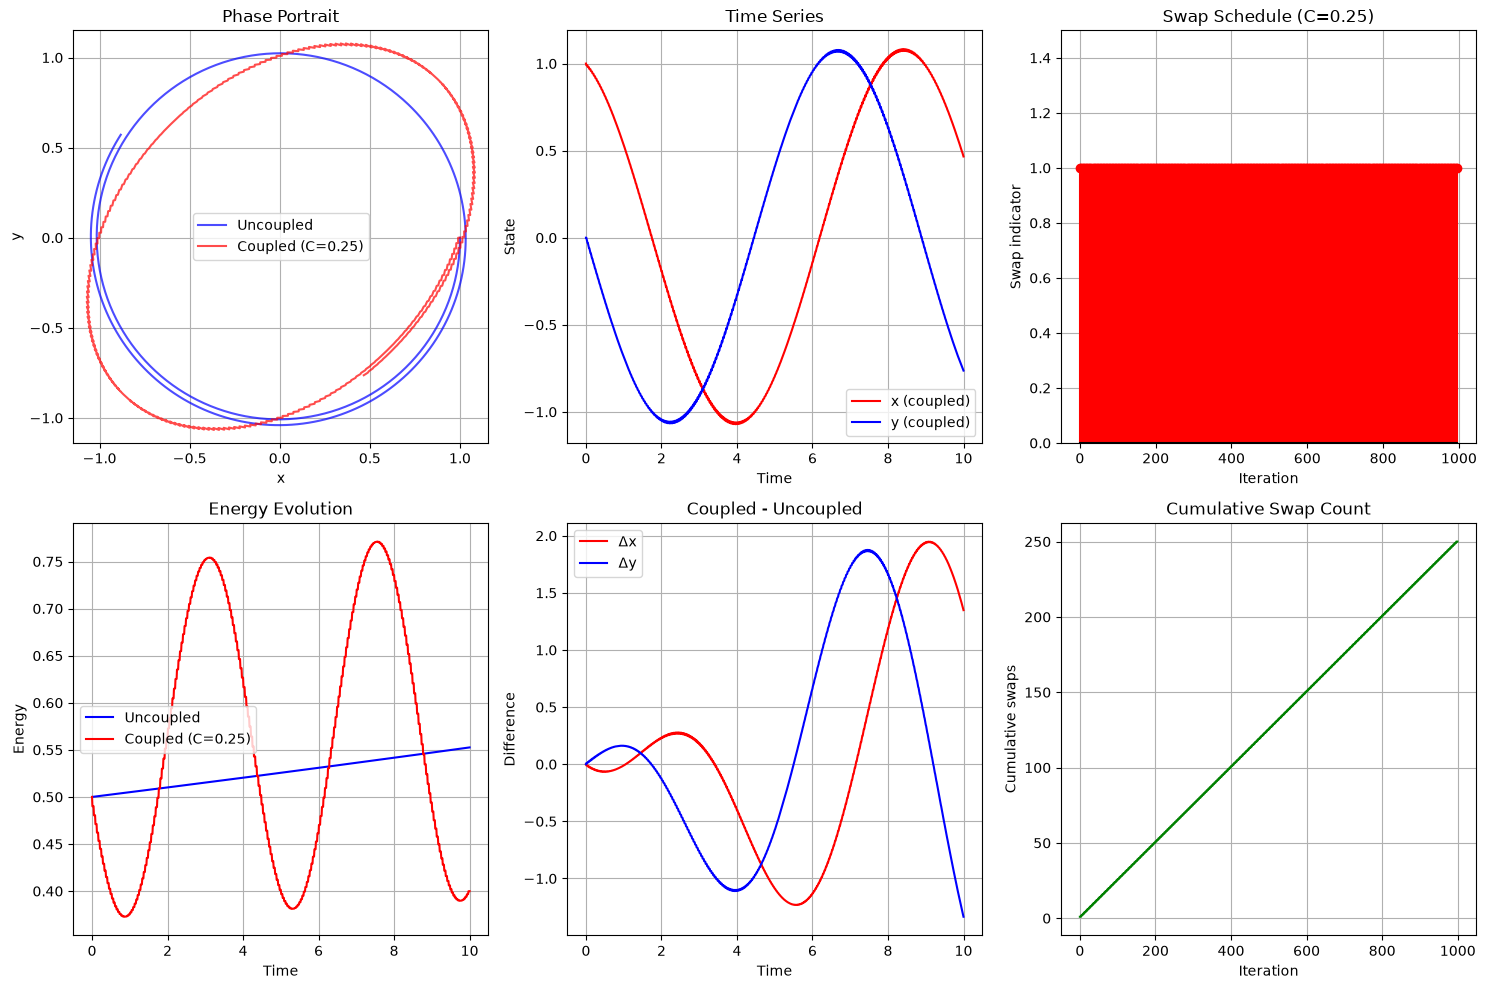

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

def generate_swap_schedule(C, N_steps, pattern='block'):
    """
    Generate a deterministic binary swap sequence with coupling coefficient C.
    
    Parameters:
    -----------
    C : float
        Coupling coefficient in [0, 1]
    N_steps : int
        Number of iterations
    pattern : str
        'block' - periodic blocks of swaps
        'alternating' - regular alternation (only for C=0.5)
        'strided' - evenly spaced swaps
    
    Returns:
    --------
    s : ndarray
        Binary swap indicator sequence
    """
    s = np.zeros(N_steps, dtype=int)
    
    if pattern == 'block':
        # For C = m/n, swap every n-th step
        if C > 0:
            period = int(round(1 / C))
            s[::period] = 1
            
    elif pattern == 'alternating':
        # Strict alternation (C = 0.5)
        s[::2] = 1
        
    elif pattern == 'strided':
        # Evenly distribute swaps
        n_swaps = int(round(C * N_steps))
        if n_swaps > 0:
            indices = np.linspace(0, N_steps - 1, n_swaps, dtype=int)
            s[indices] = 1
    
    return s

def coupled_iteration(F, x0, h, N_steps, C, pattern='block', P=None):
    """
    Perform deterministic swap-coupled iteration.
    
    Parameters:
    -----------
    F : callable
        Vector field function F(x) -> ndarray
    x0 : ndarray
        Initial state vector
    h : float
        Step size
    N_steps : int
        Number of iterations
    C : float
        Coupling coefficient
    pattern : str
        Swap schedule pattern
    P : ndarray, optional
        Permutation matrix (default: 2D swap matrix)
    
    Returns:
    --------
    trajectory : ndarray
        Array of shape (N_steps+1, n) containing all states
    s : ndarray
        Swap indicator sequence used
    """
    n = len(x0)
    
    # Default permutation matrix (2D swap)
    if P is None:
        if n == 2:
            P = np.array([[0, 1], [1, 0]])
        else:
            # For higher dimensions, swap first two components
            P = np.eye(n)
            P[0, 0], P[0, 1] = 0, 1
            P[1, 0], P[1, 1] = 1, 0
    
    # Generate swap schedule
    s = generate_swap_schedule(C, N_steps, pattern)
    
    # Initialize trajectory
    trajectory = np.zeros((N_steps + 1, n))
    trajectory[0] = x0
    
    # Iterate
    x = x0.copy()
    for k in range(N_steps):
        # Compute base increment
        dx_base = h * F(x)
        
        # Apply swap if indicated
        if s[k] == 1:
            dx = P @ dx_base
        else:
            dx = dx_base
        
        # Update state
        x = x + dx
        trajectory[k + 1] = x
    
    return trajectory, s

# Example usage
if __name__ == "__main__":
    # Define a simple 2D vector field (e.g., harmonic oscillator)
    def harmonic_oscillator(x):
        """Simple harmonic oscillator: dx/dt = y, dy/dt = -x"""
        return np.array([x[1], -x[0]])
    
    # Define a nonlinear vector field (e.g., Van der Pol oscillator)
    def van_der_pol(x, mu=1.0):
        """Van der Pol oscillator: dx/dt = y, dy/dt = mu*(1-x^2)*y - x"""
        return np.array([x[1], mu * (1 - x[0]**2) * x[1] - x[0]])
    
    # Parameters
    x0 = np.array([1.0, 0.0])  # Initial condition
    h = 0.01  # Step size
    N_steps = 1000  # Number of iterations
    C = 0.25  # Coupling coefficient
    
    # Run coupled iteration
    trajectory, swap_schedule = coupled_iteration(
        harmonic_oscillator, x0, h, N_steps, C, pattern='block'
    )
    
    # Run uncoupled iteration for comparison
    trajectory_uncoupled, _ = coupled_iteration(
        harmonic_oscillator, x0, h, N_steps, C=0.0
    )
    
    # Verify coupling coefficient
    actual_C = np.mean(swap_schedule)
    print(f"Target C: {C}")
    print(f"Actual C: {actual_C}")
    print(f"Number of swaps: {np.sum(swap_schedule)}")
    
    # Plot results
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Phase portrait
    axes[0, 0].plot(trajectory_uncoupled[:, 0], trajectory_uncoupled[:, 1], 
                    'b-', alpha=0.7, label='Uncoupled')
    axes[0, 0].plot(trajectory[:, 0], trajectory[:, 1], 
                    'r-', alpha=0.7, label=f'Coupled (C={C})')
    axes[0, 0].set_xlabel('x')
    axes[0, 0].set_ylabel('y')
    axes[0, 0].set_title('Phase Portrait')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    axes[0, 0].axis('equal')
    
    # Time series
    time = np.arange(N_steps + 1) * h
    axes[0, 1].plot(time, trajectory[:, 0], 'r-', label='x (coupled)')
    axes[0, 1].plot(time, trajectory[:, 1], 'b-', label='y (coupled)')
    axes[0, 1].set_xlabel('Time')
    axes[0, 1].set_ylabel('State')
    axes[0, 1].set_title('Time Series')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # Swap schedule visualization
    swap_indices = np.where(swap_schedule == 1)[0]
    axes[0, 2].stem(swap_indices, np.ones_like(swap_indices), 
                    linefmt='r-', markerfmt='ro', basefmt='k-')
    axes[0, 2].set_xlabel('Iteration')
    axes[0, 2].set_ylabel('Swap indicator')
    axes[0, 2].set_title(f'Swap Schedule (C={C})')
    axes[0, 2].set_ylim([0, 1.5])
    axes[0, 2].grid(True)
    
    # Energy comparison (for harmonic oscillator)
    energy_uncoupled = 0.5 * (trajectory_uncoupled[:, 0]**2 + trajectory_uncoupled[:, 1]**2)
    energy_coupled = 0.5 * (trajectory[:, 0]**2 + trajectory[:, 1]**2)
    
    axes[1, 0].plot(time, energy_uncoupled, 'b-', label='Uncoupled')
    axes[1, 0].plot(time, energy_coupled, 'r-', label=f'Coupled (C={C})')
    axes[1, 0].set_xlabel('Time')
    axes[1, 0].set_ylabel('Energy')
    axes[1, 0].set_title('Energy Evolution')
    axes[1, 0].legend()
    axes[1, 0].grid(True)
    
    # Difference between coupled and uncoupled
    diff = trajectory - trajectory_uncoupled
    axes[1, 1].plot(time, diff[:, 0], 'r-', label='Δx')
    axes[1, 1].plot(time, diff[:, 1], 'b-', label='Δy')
    axes[1, 1].set_xlabel('Time')
    axes[1, 1].set_ylabel('Difference')
    axes[1, 1].set_title('Coupled - Uncoupled')
    axes[1, 1].legend()
    axes[1, 1].grid(True)
    
    # Cumulative swap count
    cumulative_swaps = np.cumsum(swap_schedule)
    axes[1, 2].plot(range(N_steps), cumulative_swaps, 'g-')
    axes[1, 2].set_xlabel('Iteration')
    axes[1, 2].set_ylabel('Cumulative swaps')
    axes[1, 2].set_title('Cumulative Swap Count')
    axes[1, 2].grid(True)
    
    plt.tight_layout()
    plt.show()

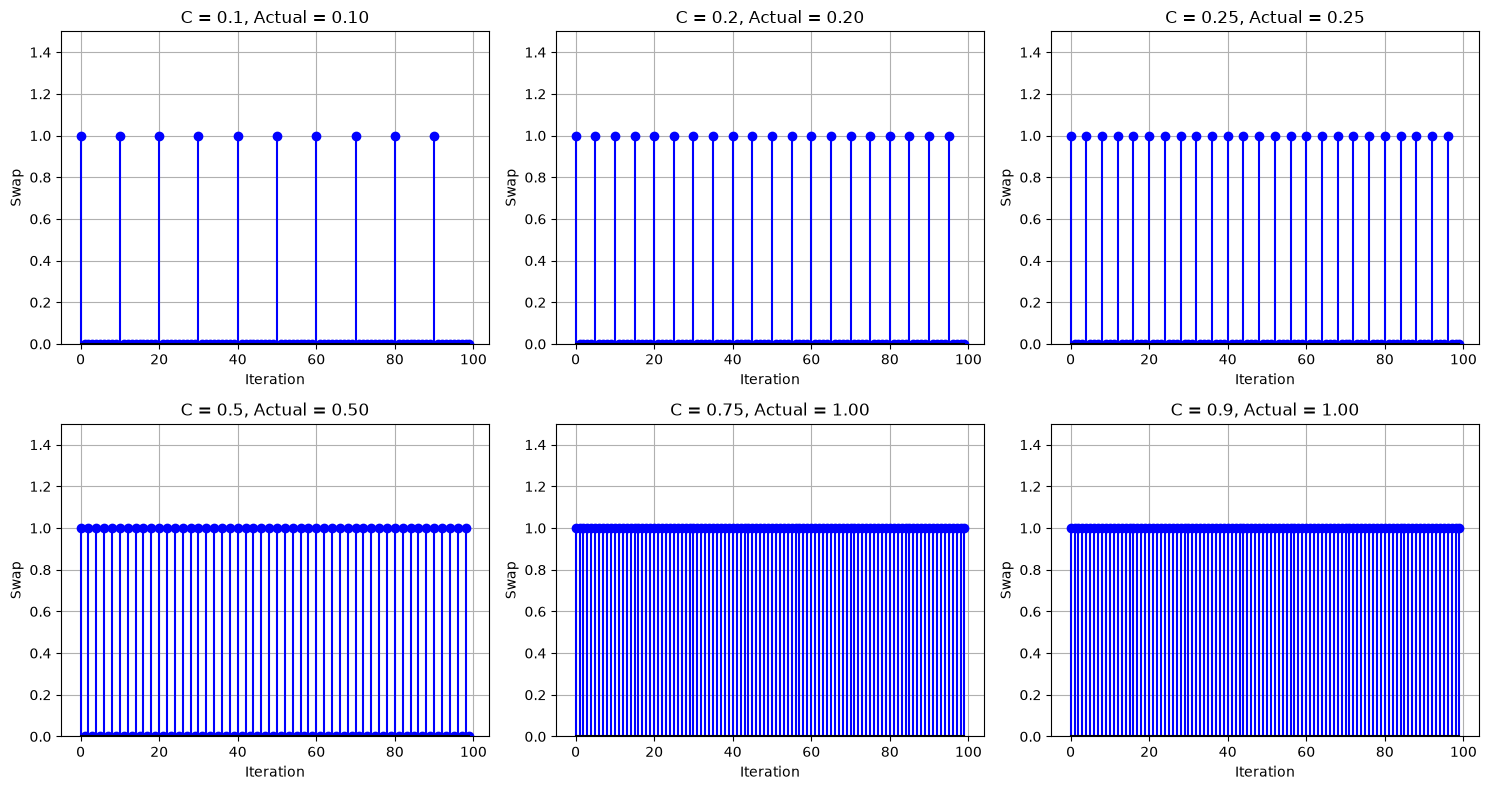

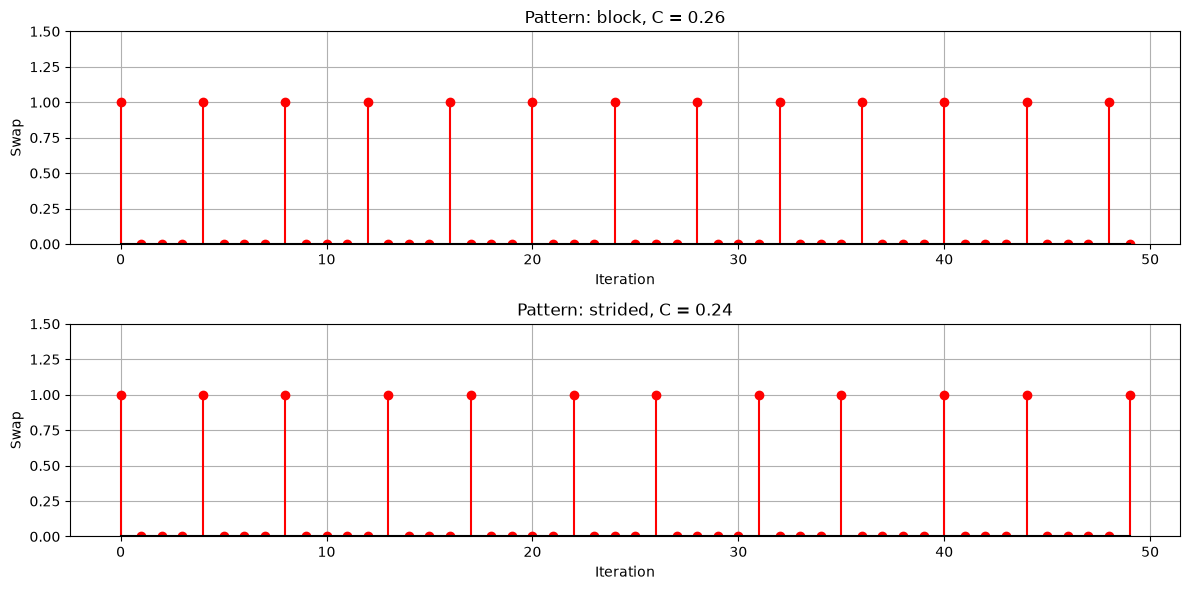

In [2]:
def analyze_coupling_patterns():
    """Analyze different coupling patterns and coefficients."""
    
    # Test different C values
    C_values = [0.1, 0.2, 0.25, 0.5, 0.75, 0.9]
    N_test = 100
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    
    for idx, C in enumerate(C_values):
        row, col = idx // 3, idx % 3
        
        # Generate schedule
        s = generate_swap_schedule(C, N_test, pattern='block')
        
        # Plot schedule
        axes[row, col].stem(range(N_test), s, linefmt='b-', markerfmt='bo', basefmt='k-')
        axes[row, col].set_title(f'C = {C}, Actual = {np.mean(s):.2f}')
        axes[row, col].set_xlabel('Iteration')
        axes[row, col].set_ylabel('Swap')
        axes[row, col].set_ylim([0, 1.5])
        axes[row, col].grid(True)
    
    plt.tight_layout()
    plt.show()

def compare_patterns():
    """Compare block, strided, and alternating patterns."""
    
    N = 50
    C = 0.25
    
    patterns = ['block', 'strided']
    if C == 0.5:
        patterns.append('alternating')
    
    fig, axes = plt.subplots(len(patterns), 1, figsize=(12, 6))
    
    for idx, pattern in enumerate(patterns):
        s = generate_swap_schedule(C, N, pattern)
        axes[idx].stem(range(N), s, linefmt='r-', markerfmt='ro', basefmt='k-')
        axes[idx].set_title(f'Pattern: {pattern}, C = {np.mean(s):.2f}')
        axes[idx].set_ylim([0, 1.5])
        axes[idx].set_xlabel('Iteration')
        axes[idx].set_ylabel('Swap')
        axes[idx].grid(True)
    
    plt.tight_layout()
    plt.show()

# Run analysis
analyze_coupling_patterns()
compare_patterns()

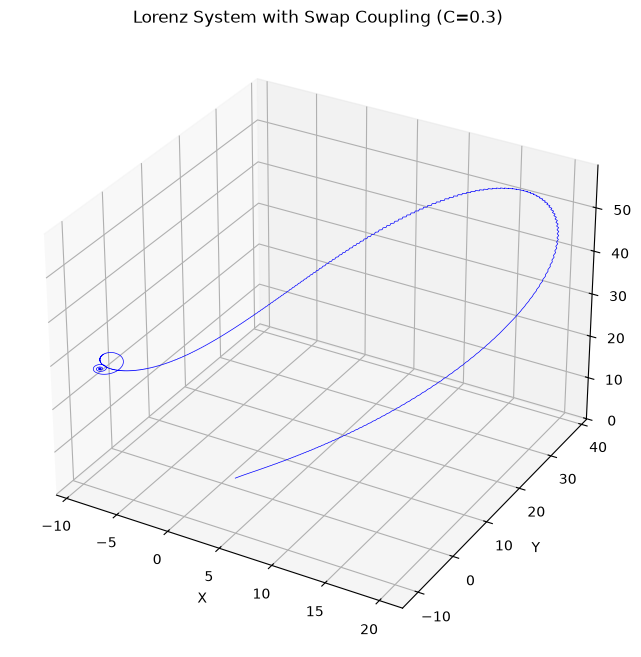

In [3]:
def coupled_iteration_multidim(F, x0, h, N_steps, C, swap_pairs, pattern='block'):
    """
    Coupled iteration for higher dimensions with multiple swap pairs.
    
    Parameters:
    -----------
    swap_pairs : list of tuples
        List of (i, j) pairs to swap
    """
    n = len(x0)
    
    # Build permutation matrix from swap pairs
    P = np.eye(n)
    for i, j in swap_pairs:
        P[i, i], P[i, j] = 0, 1
        P[j, i], P[j, j] = 1, 0
    
    # Generate swap schedule
    s = generate_swap_schedule(C, N_steps, pattern)
    
    # Initialize trajectory
    trajectory = np.zeros((N_steps + 1, n))
    trajectory[0] = x0
    
    # Iterate
    x = x0.copy()
    for k in range(N_steps):
        dx_base = h * F(x)
        
        if s[k] == 1:
            dx = P @ dx_base
        else:
            dx = dx_base
        
        x = x + dx
        trajectory[k + 1] = x
    
    return trajectory, s

# Example: 3D system with two swap pairs
def lorenz_system(x, sigma=10, rho=28, beta=8/3):
    """Lorenz system."""
    dx = sigma * (x[1] - x[0])
    dy = x[0] * (rho - x[2]) - x[1]
    dz = x[0] * x[1] - beta * x[2]
    return np.array([dx, dy, dz])

# Run 3D coupled iteration
x0_3d = np.array([1.0, 1.0, 1.0])
trajectory_3d, swaps_3d = coupled_iteration_multidim(
    lorenz_system, x0_3d, h=0.001, N_steps=5000, 
    C=0.3, swap_pairs=[(0, 1), (1, 2)]
)

# Plot 3D trajectory
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(trajectory_3d[:, 0], trajectory_3d[:, 1], trajectory_3d[:, 2], 
        'b-', linewidth=0.5)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'Lorenz System with Swap Coupling (C=0.3)')
plt.show()

# Geometric Algebra Formulation of Increment-Swap Coupling

## Preliminaries: Representing Vectors and Rotations

In Geometric Algebra (GA), we work in a Clifford algebra $\mathcal{G}(\mathbb{R}^n)$ generated by an orthonormal basis $\{e_1, e_2, \dots, e_n\}$ satisfying:

$$e_i e_j + e_j e_i = 2 \delta_{ij}$$

### Key Objects in GA

| Object | Notation | Description |
|:---|:---|:---|
| Vector | $\mathbf{x} = \sum_i x_i e_i$ | Grade-1 element |
| Bivector | $B = \sum_{i<j} B_{ij} e_i e_j$ | Grade-2 element (oriented plane) |
| Rotor | $R = e^{-B\theta/2}$ | Exponential of bivector; generates rotations |
| Geometric Product | $\mathbf{a}\mathbf{b} = \mathbf{a} \cdot \mathbf{b} + \mathbf{a} \wedge \mathbf{b}$ | Inner + outer product |

---

## Swaps as Reflections and Rotations

A swap of components $i \leftrightarrow j$ can be represented as:

1. **Reflection** across the hyperplane bisecting $e_i$ and $e_j$
2. **Rotation** by $\pi/2$ in the $e_i \wedge e_j$ plane (in 2D)

### 2D Case: Swap as Rotation

In $\mathcal{G}(\mathbb{R}^2)$, the swap $x \leftrightarrow y$ is a rotation by $-\pi/2$ in the $e_1 \wedge e_2$ plane.

Define the unit bivector:

$$I = e_1 e_2 = e_1 \wedge e_2$$

The swap rotor is:

$$R_{\text{swap}} = e^{-I \pi/4} = \cos\left(\frac{\pi}{4}\right) - I \sin\left(\frac{\pi}{4}\right) = \frac{1 - I}{\sqrt{2}}$$

The swap operation on a vector $\mathbf{v} = v_x e_1 + v_y e_2$ is:

$$\mathbf{v}' = R_{\text{swap}} \, \mathbf{v} \, \widetilde{R}_{\text{swap}}$$

where $\widetilde{R}_{\text{swap}} = \frac{1 + I}{\sqrt{2}}$ is the reverse of $R_{\text{swap}}$.

**Verification:**

$$R_{\text{swap}} \, (v_x e_1 + v_y e_2) \, \widetilde{R}_{\text{swap}} = v_y e_1 + v_x e_2$$

---

## Continuous Swap Coupling in GA

The continuous coupled vector field in GA notation:

$$\mathbf{F}^{(\sigma)}(\mathbf{x}) = (1-\sigma) \mathbf{F}(\mathbf{x}) + \sigma \, R_{\text{swap}} \, \mathbf{F}(\mathbf{x}) \, \widetilde{R}_{\text{swap}}$$

Equivalently, as a **rotor interpolation**:

$$\mathbf{F}^{(\sigma)}(\mathbf{x}) = R_{\sigma} \, \mathbf{F}(\mathbf{x}) \, \widetilde{R}_{\sigma}$$

where the interpolated rotor is:

$$R_{\sigma} = e^{-I \sigma \pi / 4} = \cos\left(\frac{\sigma \pi}{4}\right) - I \sin\left(\frac{\sigma \pi}{4}\right)$$

> **Note:** Unlike the matrix formulation $[(1-\sigma)I + \sigma P]$, the rotor formulation $R_\sigma$ is a **continuous path through rotation space**, but it does **not** preserve the vector's magnitude unless $\sigma \in \{0, 1\}$. The matrix formulation is a convex combination; the rotor formulation is a geodesic interpolation in rotation space.

---

## Discrete Deterministic Swap in GA

### Core Iteration

Given state $\mathbf{x}^{(k)} \in \mathbb{R}^n$ (as a GA vector), the iteration is:

**Step 1 — Compute base increment (as GA vector):**

$$\Delta \mathbf{x}_{\text{base}}^{(k)} = h \, \mathbf{F}(\mathbf{x}^{(k)})$$

**Step 2 — Apply deterministic swap via rotor:**

$$\Delta \mathbf{x}^{(k)} = \begin{cases} \Delta \mathbf{x}_{\text{base}}^{(k)} & \text{if } s_k = 0 \\[0.5em] R_{\text{swap}} \, \Delta \mathbf{x}_{\text{base}}^{(k)} \, \widetilde{R}_{\text{swap}} & \text{if } s_k = 1 \end{cases}$$

**Step 3 — Update state:**

$$\mathbf{x}^{(k+1)} = \mathbf{x}^{(k)} + \Delta \mathbf{x}^{(k)}$$

---

## Worked Example: 2D Harmonic Oscillator with $C = 0.25$

### Setup

- Vector field: $\mathbf{F}(\mathbf{x}) = y e_1 - x e_2$
- Swap rotor: $R_{\text{swap}} = \frac{1 - I}{\sqrt{2}}$, where $I = e_1 e_2$
- Swap schedule: $\{s_k\} = \{1, 0, 0, 0, 1, 0, 0, 0, \dots\}$
- Initial state: $\mathbf{x}^{(0)} = 1 e_1 + 0 e_2 = e_1$

---

### Iteration $k = 0$ (Swap: $s_0 = 1$)

**Base increment:**

$$\Delta \mathbf{x}_{\text{base}}^{(0)} = h \, \mathbf{F}(e_1) = h(0 \cdot e_1 - 1 \cdot e_2) = -h e_2$$

**Apply swap rotor:**

$$\Delta \mathbf{x}^{(0)} = R_{\text{swap}} (-h e_2) \widetilde{R}_{\text{swap}}$$

Compute:

$$R_{\text{swap}} (-h e_2) \widetilde{R}_{\text{swap}} = -h \left( \frac{1 - I}{\sqrt{2}} \right) e_2 \left( \frac{1 + I}{\sqrt{2}} \right)$$

Using $I e_2 = e_1 e_2 e_2 = e_1 (e_2 e_2) = e_1$ and $e_2 I = e_2 e_1 e_2 = -e_1 e_2 e_2 = -e_1$:

$$= -\frac{h}{2} \left( e_2 - I e_2 + e_2 I - I e_2 I \right) = -\frac{h}{2} \left( e_2 - e_1 - e_1 - e_2 \right) = -\frac{h}{2}(-2 e_1) = h e_1$$

**State update:**

$$\mathbf{x}^{(1)} = e_1 + h e_1 = (1 + h) e_1$$

> **Key observation:** The increment that was originally $-h e_2$ (pointing in the $-y$ direction) has been rotated by $-\pi/2$ to become $h e_1$ (pointing in the $+x$ direction). This is exactly the swap $F_y \leftrightarrow F_x$.

---

### Iteration $k = 1$ (No swap: $s_1 = 0$)

**Base increment:**

$$\Delta \mathbf{x}_{\text{base}}^{(1)} = h \, \mathbf{F}((1+h) e_1) = h(0 \cdot e_1 - (1+h) e_2) = -h(1+h) e_2$$

**No swap:**

$$\Delta \mathbf{x}^{(1)} = -h(1+h) e_2$$

**State update:**

$$\mathbf{x}^{(2)} = (1+h) e_1 - h(1+h) e_2$$

---

### Iteration $k = 2$ (No swap: $s_2 = 0$)

**Base increment:**

$$\Delta \mathbf{x}_{\text{base}}^{(2)} = h \left[ -h(1+h) e_1 - (1+h) e_2 \right] = -h^2(1+h) e_1 - h(1+h) e_2$$

**State update:**

$$\mathbf{x}^{(3)} = \left[ (1+h) - h^2(1+h) \right] e_1 + \left[ -h(1+h) - h(1+h) \right] e_2$$

$$= (1+h)(1 - h^2) e_1 - 2h(1+h) e_2$$

---

### Iteration $k = 3$ (No swap: $s_3 = 0$)

**Base increment:**

$$\Delta \mathbf{x}_{\text{base}}^{(3)} = h \left[ -2h(1+h) e_1 - (1+h)(1-h^2) e_2 \right]$$

$$= -2h^2(1+h) e_1 - h(1+h)(1-h^2) e_2$$

**State update:**

$$\mathbf{x}^{(4)} = \left[ (1+h)(1-h^2) - 2h^2(1+h) \right] e_1 + \left[ -2h(1+h) - h(1+h)(1-h^2) \right] e_2$$

$$= (1+h)(1 - 3h^2) e_1 - h(1+h)(3 - h^2) e_2$$

---

### Iteration $k = 4$ (Swap: $s_4 = 1$)

**Base increment:**

$$\Delta \mathbf{x}_{\text{base}}^{(4)} = h \left[ -h(1+h)(3-h^2) e_1 - (1+h)(1-3h^2) e_2 \right]$$

$$= -h^2(1+h)(3-h^2) e_1 - h(1+h)(1-3h^2) e_2$$

**Apply swap rotor (rotate by $-\pi/2$):**

$$\Delta \mathbf{x}^{(4)} = R_{\text{swap}} \Delta \mathbf{x}_{\text{base}}^{(4)} \widetilde{R}_{\text{swap}} = h(1+h)(1-3h^2) e_1 - h^2(1+h)(3-h^2) e_2$$

**State update:**

$$\mathbf{x}^{(5)} = \left[ (1+h)(1-3h^2) + h(1+h)(1-3h^2) \right] e_1 + \left[ -h(1+h)(3-h^2) - h^2(1+h)(3-h^2) \right] e_2$$

$$= (1+h)^2(1-3h^2) e_1 - h(1+h)^2(3-h^2) e_2$$

---

## Summary of Rotor-Based Swap

| Iteration $k$ | $s_k$ | Increment $\Delta \mathbf{x}^{(k)}$ | State $\mathbf{x}^{(k+1)}$ |
|:---:|:---:|:---:|:---:|
| 0 | 1 | $h e_1$ | $(1+h) e_1$ |
| 1 | 0 | $-h(1+h) e_2$ | $(1+h)e_1 - h(1+h)e_2$ |
| 2 | 0 | $-h^2(1+h)e_1 - h(1+h)e_2$ | $(1+h)(1-h^2)e_1 - 2h(1+h)e_2$ |
| 3 | 0 | $-2h^2(1+h)e_1 - h(1+h)(1-h^2)e_2$ | $(1+h)(1-3h^2)e_1 - h(1+h)(3-h^2)e_2$ |
| 4 | 1 | $h(1+h)(1-3h^2)e_1 - h^2(1+h)(3-h^2)e_2$ | $(1+h)^2(1-3h^2)e_1 - h(1+h)^2(3-h^2)e_2$ |

---

## Geometric Interpretation

### The Swap as a Bivector Operation

The permutation matrix $P = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$ in GA corresponds to a **reflection** across the line $y = x$, which can be decomposed as:

$$P = \text{Reflection}_{y=x} = -R_{\text{swap}}^2$$

where $R_{\text{swap}} = e^{-I \pi/4}$ is the rotor generating a $\pi/2$ rotation.

Equivalently, the swap is a **rotation by $\pi/2$ followed by a reflection**:

$$\text{Swap} = R_{\text{swap}} \circ \text{Reflection}_{e_1}$$

### Why Use GA?

| Advantage | Description |
|:---|:---|
| **Coordinate-free** | The swap is expressed as a geometric operation (rotation/reflection) rather than index manipulation |
| **Dimension-agnostic** | The same rotor formulation extends to higher dimensions via bivector planes |
| **Compositional** | Multiple swaps compose as rotor products: $R_{\text{total}} = R_2 R_1$ |
| **Interpolation** | Smooth coupling corresponds to rotor interpolation: $R_\sigma = e^{-I \sigma \pi/4}$ |
| **Geometric insight** | Reveals that swapping is a $\pi/2$ rotation in the $e_i \wedge e_j$ plane |

---

## Higher-Dimensional Swaps

For swapping components $i$ and $j$ in $\mathbb{R}^n$:

1. Define the unit bivector: $B_{ij} = e_i \wedge e_j = e_i e_j$
2. Define the swap rotor: $R_{ij} = e^{-B_{ij} \pi/4} = \frac{1 - B_{ij}}{\sqrt{2}}$
3. Apply to any vector $\mathbf{v}$: $\mathbf{v}' = R_{ij} \, \mathbf{v} \, \widetilde{R}_{ij}$

For **multiple simultaneous swaps** (e.g., $0 \leftrightarrow 1$ and $2 \leftrightarrow 3$):

$$R_{\text{multi}} = R_{01} R_{23} = e^{-B_{01} \pi/4} \, e^{-B_{23} \pi/4}$$

Since $B_{01}$ and $B_{23}$ commute (disjoint planes), $R_{\text{multi}}$ is well-defined.

---

## Deterministic Swap Schedule in GA

The swap indicator sequence $\{s_k\}$ remains unchanged from the matrix formulation. The GA formulation only affects **how the swap is applied to the increment vector**:

$$\Delta \mathbf{x}^{(k)} = \begin{cases} \Delta \mathbf{x}_{\text{base}}^{(k)} & \text{if } s_k = 0 \\[0.5em] R_{\text{swap}} \, \Delta \mathbf{x}_{\text{base}}^{(k)} \, \widetilde{R}_{\text{swap}} & \text{if } s_k = 1 \end{cases}$$

The coupling coefficient is still:

$$C_N = \frac{1}{N} \sum_{k=0}^{N-1} s_k$$

---

## Compact GA Pseudo-code

```
Input: x(0), h, F, R_swap, {s_k} for k = 0, ..., N-1

for k = 0 to N-1:
    dx_base = h * F(x(k))                    # GA vector
    if s_k == 0:
        dx = dx_base                         # no swap
    else:
        dx = R_swap * dx_base * ~R_swap      # apply rotor swap
    x(k+1) = x(k) + dx                       # update state

C_N = (1/N) * sum(s_k)                       # coupling coefficient
```